In [21]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
pip install --upgrade --force-reinstall matplotlib ydata-profiling

  Using cached ydata_profiling-4.18.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached matplotlib-3.10.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached minify_html-0.18.1-cp313-cp313-win_amd64.whl.metadata (18 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached phik-0.12.5-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
  Using cached 

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
error: uninstall-no-record-file

Cannot uninstall matplotlib 3.10.0

The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.10.0


In [38]:
true_df=pd.read_csv(r'C:\Users\prash\Downloads\fake-news\True.csv')
fake_df=pd.read_csv(r'C:\Users\prash\Downloads\fake-news\Fake.csv')

true_df['label']=1
fake_df['label']=0

df=pd.concat([true_df,fake_df],ignore_index=True)
df=df.sample(frac=1).reset_index(drop=True)

print(df.shape)
df.head()
    


(44898, 5)


,title,text,subject,date,label
0,BREAKING: Megyn Kelly Just Gave The Ultimate ...,It seems that Fox News repeated decisions to ...,News,"January 3, 2017",0
1,BOOM! WATCH SEAN HANNITY Hit Back At Bogus Sex...,Thank you Sean Hannity for hitting back at the...,left-news,"Apr 24, 2017",0
2,Trump nominates Democrat Rosenworcel to serve ...,WASHINGTON (Reuters) - The U.S. Senate will ag...,politicsNews,"June 14, 2017",1
3,RATINGS FOR NBC’S Backstabbing Megyn Kelly Are...,"Last week, Alex Jones scooped NBC and Megyn Ke...",politics,"Jun 19, 2017",0
4,"'Political mainstream', Corbyn says Britain's ...","BRIGHTON, England (Reuters) - Opposition leade...",worldnews,"September 26, 2017",1


Exploring the data ... 

In [39]:
print(df.info)

<bound method DataFrame.info of                                                    title  \
0       BREAKING: Megyn Kelly Just Gave The Ultimate ...   
1      BOOM! WATCH SEAN HANNITY Hit Back At Bogus Sex...   
2      Trump nominates Democrat Rosenworcel to serve ...   
3      RATINGS FOR NBC’S Backstabbing Megyn Kelly Are...   
4      'Political mainstream', Corbyn says Britain's ...   
...                                                  ...   
44893  Kerry says raised Democrat email hack with Rus...   
44894   WATCH: This Is How President Obama And Donald...   
44895  #HAMILTON Star Makes Jokes On Twitter About “B...   
44896   Rick Perry’s Confirmation Hearing Just Got Ex...   
44897  WOW! CONFIRMED BY ICE: 5-Time Deported ILLEGAL...   

                                                    text       subject  \
0      It seems that Fox News  repeated decisions to ...          News   
1      Thank you Sean Hannity for hitting back at the...     left-news   
2      WASHINGTON (Reuter

In [43]:

print("\n Missing Values\n",df.isnull().sum())



 Missing Values
 title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [44]:
print("\n Class Labels \n",df['label'].value_counts())


 Class Labels 
 label
0    23481
1    21417
Name: count, dtype: int64


Data Visualisation 

C:\Users\prash\AppData\Local\Temp\ipykernel_31460\2384306051.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2', legend=False)


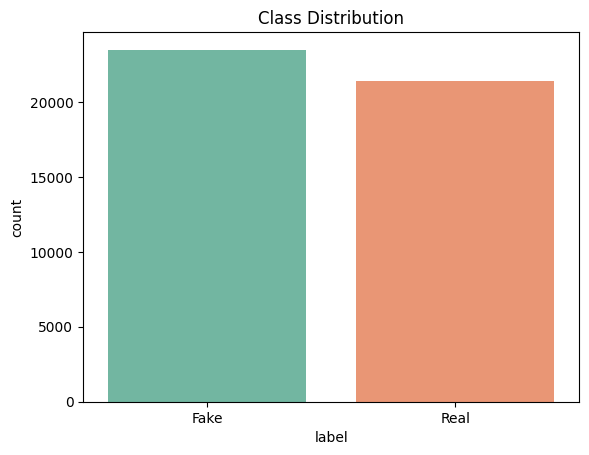

In [67]:
sns.countplot(x='label', data=df, palette='Set2', legend=False)
plt.xticks([0,1], ['Fake','Real'])
plt.title('Class Distribution')
plt.savefig('../data/class_distribution.png')
plt.show()   

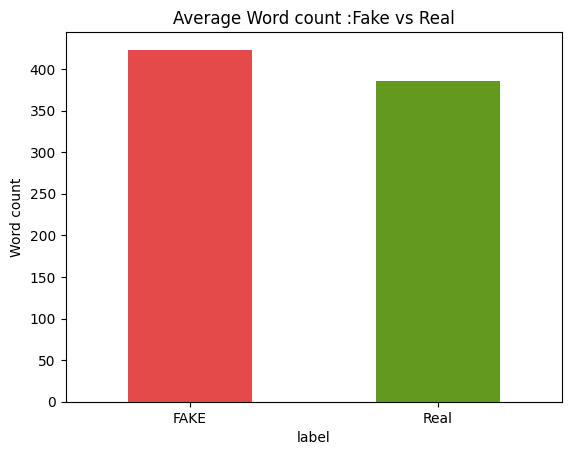

In [60]:
df['text_length']=df['text'].apply(lambda x:len(str(x).split()))
df.groupby('label')['text_length'].mean().plot(kind='bar',color=['#E24B4A','#63991F'])
plt.xticks([0,1],['FAKE','Real'],rotation=0)
plt.title('Average Word count :Fake vs Real')
plt.ylabel('Word count')
plt.show()

Text Processing

In [72]:
import re
import string 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('NLP TOOLS READY')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...


NLP TOOLS READY


In [77]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [78]:
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r'\[.*?\]','',text)
    text=re.sub(r'https?://\S+|www\.\S+','',text)
    text=re.sub(r'<.*?>+','',text)
    text=re.sub(r'[%s]' % re.escape(string.punctuation),'',text)
    text=re.sub(r'\n','',text)
    text=re.sub(r'\w*\d\w*','',text)
    text=re.sub(r'\w*\d\w*','',text)
    tokens=text.split()
    tokens=[lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_text']=df['text'].apply(clean_text)
print("Cleaning done")
df[['text','clean_text']].head(3)

Cleaning done


,text,clean_text
0,It seems that Fox News repeated decisions to ...,seems fox news repeated decision shower donald...
1,Thank you Sean Hannity for hitting back at the...,thank sean hannity hitting back latest woman c...
2,WASHINGTON (Reuters) - The U.S. Senate will ag...,washington reuters u senate consider jessica r...


In [79]:
    
def clean_text(text):
    text = str(text).lower()                             
    text = re.sub(r'\[.*?\]', '', text)                 
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   
    text = re.sub(r'<.*?>+', '', text)                   
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)   
    text = re.sub(r'\n', '', text)                       
    text = re.sub(r'\w*\d\w*', '', text)                
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

 
df['clean_text'] = df['text'].apply(clean_text)
print("Cleaning done!")
df[['text', 'clean_text']].head(3)

Cleaning done!


,text,clean_text
0,It seems that Fox News repeated decisions to ...,seems fox news repeated decision shower donald...
1,Thank you Sean Hannity for hitting back at the...,thank sean hannity hitting back latest woman c...
2,WASHINGTON (Reuters) - The U.S. Senate will ag...,washington reuters u senate consider jessica r...


In [82]:
df['combined']=df['title']+' '+df['clean_text']
df[['combined','label']].head(3)

,combined,label
0,BREAKING: Megyn Kelly Just Gave The Ultimate ...,0
1,BOOM! WATCH SEAN HANNITY Hit Back At Bogus Sex...,0
2,Trump nominates Democrat Rosenworcel to serve ...,1


In [84]:
df[['combined','label']].to_csv('../data/processed_data.csv',index=False)
print("Processed Data saved")

Processed Data saved


Feature Engnnering  + Model Training

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve)
from sklearn.pipeline import Pipeline
import joblib 
print("ML libraries ready")

ML libraries ready


In [95]:
x=df['combined']
y=df['label']

X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print(f"Training samples,{len(X_train)}")
print(f"Testing Samples :,{len(X_test)}")


Training samples,35918
Testing Samples :,8980


In [97]:
 
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (35918, 50000)


In [114]:
models={
    'Logistic Regression':LogisticRegression(max_iter=1000),
    'Naive Bayes':MultinomialNB(),
    'Linear SVM':LinearSVC(),
    'Random Forest':RandomForestClassifier(n_estimators=100,random_state=42)
}
result={}
for name,model  in models.items():
    model.fit(X_train_tfidf,Y_train)
    y_pred=model.predict(X_test_tfidf)
    acc=accuracy_score(Y_test,y_pred)
    result[name]=acc
    print(f"{name:25s}=>Accuracy :{acc:.4f}")
    

Logistic Regression      =>Accuracy :0.9884
Naive Bayes              =>Accuracy :0.9524
Linear SVM               =>Accuracy :0.9958
Random Forest            =>Accuracy :0.9952


In [115]:
 
plt.figure(figsize=(10, 5))
plt.barh(list(results.keys()), list(results.values()), color='#378ADD')
plt.xlim(0.9, 1.0)
plt.xlabel('Accuracy')
plt.title('Model Comparison')
for i, (k, v) in enumerate(results.items()):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.savefig('../data/model_comparison.png')
plt.show()

NameError: name 'results' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
 
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../data/confusion_matrix.png')
plt.show()

In [119]:
 
best_model = models['Logistic Regression']    
y_pred = best_model.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(Y_test, y_pred, target_names=['Fake','Real']))

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



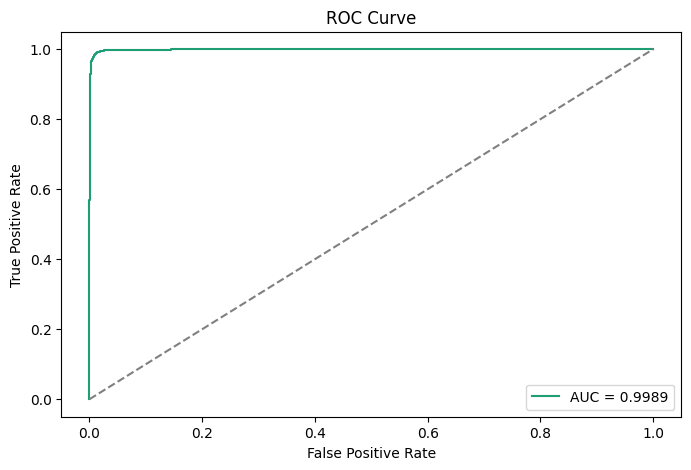

In [120]:
 
y_prob = best_model.decision_function(X_test_tfidf)
fpr, tpr, _ = roc_curve(Y_test, y_prob)
auc = roc_auc_score(Y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='#1D9E75')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('../data/roc_curve.png')
plt.show()

In [121]:
joblib.dump(best_model,'../models/model.pkl')
joblib.dump(tfidf,'../models/tfidf.pkl')
print("Model and vectorizer saved to models/folder")

Model and vectorizer saved to models/folder


In [122]:
import streamlit as st
import joblib
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

# Load model and vectorizer
model = joblib.load('../models/model.pkl')
tfidf = joblib.load('../models/tfidf.pkl')

stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# --- UI ---
st.set_page_config(page_title="Fake News Detector", page_icon="📰", layout="centered")

st.title("📰 Fake News Detector")
st.markdown("Enter a news article below and the model will predict if it is **Real** or **Fake**.")

user_input = st.text_area("Paste your news article here:", height=200)

if st.button("Analyze"):
    if user_input.strip() == "":
        st.warning("Please enter some text first.")
    else:
        cleaned   = clean_text(user_input)
        vectorized = tfidf.transform([cleaned])
        prediction = model.predict(vectorized)[0]

        if prediction == 1:
            st.success("✅ This news appears to be REAL")
        else:
            st.error("❌ This news appears to be FAKE")

        st.markdown("---")
        st.caption("Model: Logistic Regression + TF-IDF | Dataset: ISOT")

2026-03-25 02:13:54.972 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 02:13:54.974 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 02:13:55.693 
  command:

    streamlit run C:\Users\prash\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-25 02:13:55.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 02:13:55.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 02:13:55.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 02:13:55.696 Thread 'MainThread': missing ScriptRunContext! This warning can b